### Модуль 7. Финансовый аналитик

### Цель задания

Сегодня ты “Финансовый аналитик” - изучи и проанализируй внутренние финансы компании и финансовые показатели партнеров, конкурентов или стартапов, в которые компания хочет инвестировать.В частности: макроэкономические и микроэкономические условия наряду с фундаментальными показателями компании.Рекомендуй курс действий для руководства по покупке или продаже акций компании, исходя из ее общих показателей и перспектив. Проведи критический анализ архитектуры DataLake.

### Навыки

|Архитектура|Базы данных|Форматы данных|Инструменты|Коммуникации|
|-----------|-----------|--------------|-----------|------------|
|Событийная|GreenPlum|DeltaLake|Обучение  с подкреплением AsyncioRED Dagster Стандарт AsyncAPI Безопасность модели|Все отделы компании, банки|


### Условия

Можно пользоваться любыми языковыми моделями

###  Формат сдачи и отправка задания

Итоговый блокнот нужно разместить на GitLab либо на GitHub ("запушить" в любом формате .py или .ipynb)
и поделиться ссылкой на файл (убедившись, что видимости репозитория).

###  Сроки выполнения задания

Максимум одна неделя, сданные после истечения максимального срока  работы не проверяются.

###  Критерии оценивания

| Критерий                 | Вес | Описание                                                                                                                                                                                              |
|--------------------------|-----|----------------------------------------------------------|
| Выбор алгоритма          | 15% | Оценка уместности выбранного алгоритма для данной задачи.|
| Точность реализации      | 15% | Оценка корректности реализации алгоритма.                |
| Основная функциональность| 20% | Оценка степени выполнения основных требований задания.   |
| Обработка крайних случаев| 10% | Оценка кода по обработке граничных входных данных.       |
| Документация к коду      | 10% | Оценка ясности и полноты комментариев в коде.            |
| Объяснение результатов   | 10% | Оценка четкости объясненния результатов работы кода      |
| Стиль кода               | 10% | Оценка читаемости кода и соответствия PEP-8              |
| Анализ ошибок и отладка  | 10% | Оценка способности студента выявлять и исправлять ошибки |


**Максимальный балл за выполненную домашнюю работу: 10 баллов**

**Дополнительные условия оценки:**

Можно сдать работу через обычный Google Colab без начисления штрафных баллов и поделиться ссылкой на файл.

**Как будет проверяться:**

Работа будет проверяться преподавателем вручную в течение максимум одной недели.

### Задание №1

Подключи расширение RAPIDS cuDF командой ```%load_ext cudf.pandas``` и измерь ускорение работы pandas на графическом процессоре GPU


In [ ]:
%%capture
# установка занимает 3 минуты
!git clone https://github.com/rapidsai/rapidsai-csp-utils.git
!python rapidsai-csp-utils/colab/pip-install.py
!pip install pandas gdown torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

In [1]:
import cudf
import pandas as pd
import gdown
url = "https://drive.google.com/uc?export=download&id=1HRajTCSQCaMJea_mrQKeSuI5BeLApgnT"
output = "Stock_Data.zip"
gdown.download(url, output)
!rm /content/all_stocks_5yr.csv -f
!unzip Stock_Data.zip
df = pd.read_csv("/content/all_stocks_5yr.csv", header = 0, sep = ',')
df.head(1)

Downloading...
From: https://drive.google.com/uc?export=download&id=1HRajTCSQCaMJea_mrQKeSuI5BeLApgnT
To: /content/Stock_Data.zip
100%|██████████| 10.1M/10.1M [00:00<00:00, 40.2MB/s]


Archive:  Stock_Data.zip
  inflating: all_stocks_5yr.csv      


,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL


In [ ]:
big_df = pd.concat([df]*250,ignore_index=True);big_df.info() # увеличенный в 250 раз набор данных занял почти всю памть

<class 'cudf.core.dataframe.DataFrame'>
RangeIndex: 154760000 entries, 0 to 154759999
Data columns (total 7 columns):
 #   Column  Dtype
---  ------  -----
 0   date    object
 1   open    float64
 2   high    float64
 3   low     float64
 4   close   float64
 5   volume  int64
 6   Name    object
dtypes: float64(4), int64(1), object(2)
memory usage: 8.9+ GB


In [ ]:
%%time

(big_df
 .groupby(["Name"])
 .agg({"close": "mean"})
 .rename(columns={"close": "mean_close_price"})
 .sort_values(["mean_close_price"], ascending=False)
) #обрабатываем 154 миллиона строк на GPU за 0,6 сек

CPU times: user 9.09 s, sys: 1.99 s, total: 11.1 s
Wall time: 11.2 s


,mean_close_price
Name,
PCLN,1312.873538
GOOG,725.403353
GOOGL,682.233847
AZO,619.703654
AMZN,576.880041
...,...
CHK,13.681326
AES,12.340048
RF,10.935608


In [ ]:
%load_ext cudf.pandas

In [ ]:
%%time
(big_df
 .groupby(["Name"])
 .agg({"close": "mean"})
 .rename(columns={"close": "mean_close_price"})
 .sort_values(["mean_close_price"], ascending=False)
)

CPU times: user 262 ms, sys: 475 ms, total: 737 ms
Wall time: 806 ms


,mean_close_price
Name,
PCLN,1312.873538
GOOG,725.403353
GOOGL,682.233847
AZO,619.703654
AMZN,576.880041
...,...
CHK,13.681326
AES,12.340048
RF,10.935608


9.09 секунд на CPU, 262 милисекунд на GPU

### Задание №2

Инжиниринг признаков — это создание новых признаков на основе существующих признаков. Создадим новый признак "день недели" из колонки "date". Подтверди или опровергни гипотезу о том, что день недели влияет на объём торгов (одной любой акции на свой выбор)

In [2]:
df['timestamp'] = pd.to_datetime(df['date'])
df['day_of_week'] = df['timestamp'].dt.dayofweek  # Извлекаем день недели (0=понедельник, 6=воскресенье)
df.head(1) # датафрейм с новым признаком

,date,open,high,low,close,volume,Name,timestamp,day_of_week
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL,2013-02-08,4


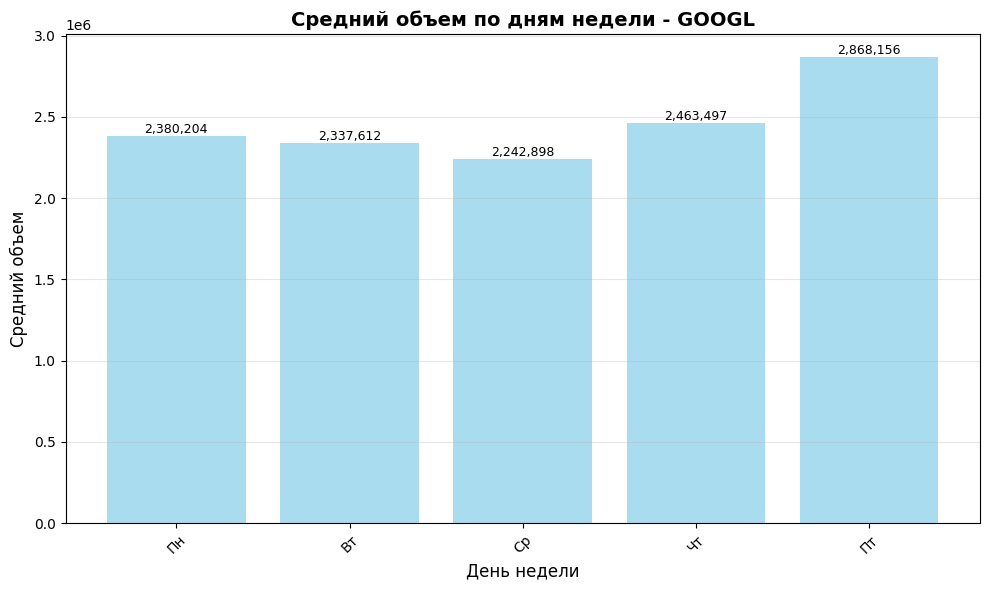

In [3]:
import matplotlib.pyplot as plt

googl_df = df[df['Name'] == 'GOOGL']
volume_by_day = googl_df.groupby('day_of_week')['volume'].mean()
plt.figure(figsize=(10, 6))
bars = plt.bar(volume_by_day.index, volume_by_day.values, color='skyblue', alpha=0.7)
plt.title('Средний объем по дням недели - GOOGL', fontsize=14, fontweight='bold')
plt.xlabel('День недели', fontsize=12)
plt.ylabel('Средний объем', fontsize=12)
day_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
plt.xticks(volume_by_day.index, [day_names[i] for i in volume_by_day.index], rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:,.0f}',
             ha='center', va='bottom', fontsize=9)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

На графике видно, что в пятницу объем торгов для акций ГУГЛ наибольший, в среду - самый низкий

Проверим эту теорию с помощью статисчтических тестов (ANOVA)

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

volume_data_by_day = [group['volume'].values for name, group in googl_df.groupby('day_of_week')]
f_stat, p_value = stats.f_oneway(*volume_data_by_day)

print(f"ANOVA F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"Статистически значимые различия обнаружены (p < {alpha})")
    print("Средние объемы торгов значительно различаются по дням недели")
else:
    print(f"Статистически значимых различий не обнаружено (p ≥ {alpha})")
    print("Средние объемы торгов не различаются significantly по дням недели")

print(f"\n=== Дополнительная статистика ===")
print(f"Общее количество наблюдений: {len(googl_df)}")
print(f"Количество наблюдений по дням:")
for day in sorted(googl_df['day_of_week'].unique()):
    count = len(googl_df[googl_df['day_of_week'] == day])
    print(f"  {day_names[int(day)]}: {count} наблюдений")

ANOVA F-statistic: 5.9743
P-value: 0.0001
Статистически значимые различия обнаружены (p < 0.05)
Средние объемы торгов значительно различаются по дням недели

=== Дополнительная статистика ===
Общее количество наблюдений: 1259
Количество наблюдений по дням:
  Пн: 236 наблюдений
  Вт: 260 наблюдений
  Ср: 259 наблюдений
  Чт: 252 наблюдений
  Пт: 252 наблюдений


Таким образом, наша теория подтвердилась

### Задание №3

Рассчитай технический индикатор "полосы Боллинджера" по имеющимся (хранящимся, статическим) данным

In [ ]:
!pip install numpy==1.26.4

In [ ]:
!pip install TA-Lib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 114.8 MB/s eta 0:00:00


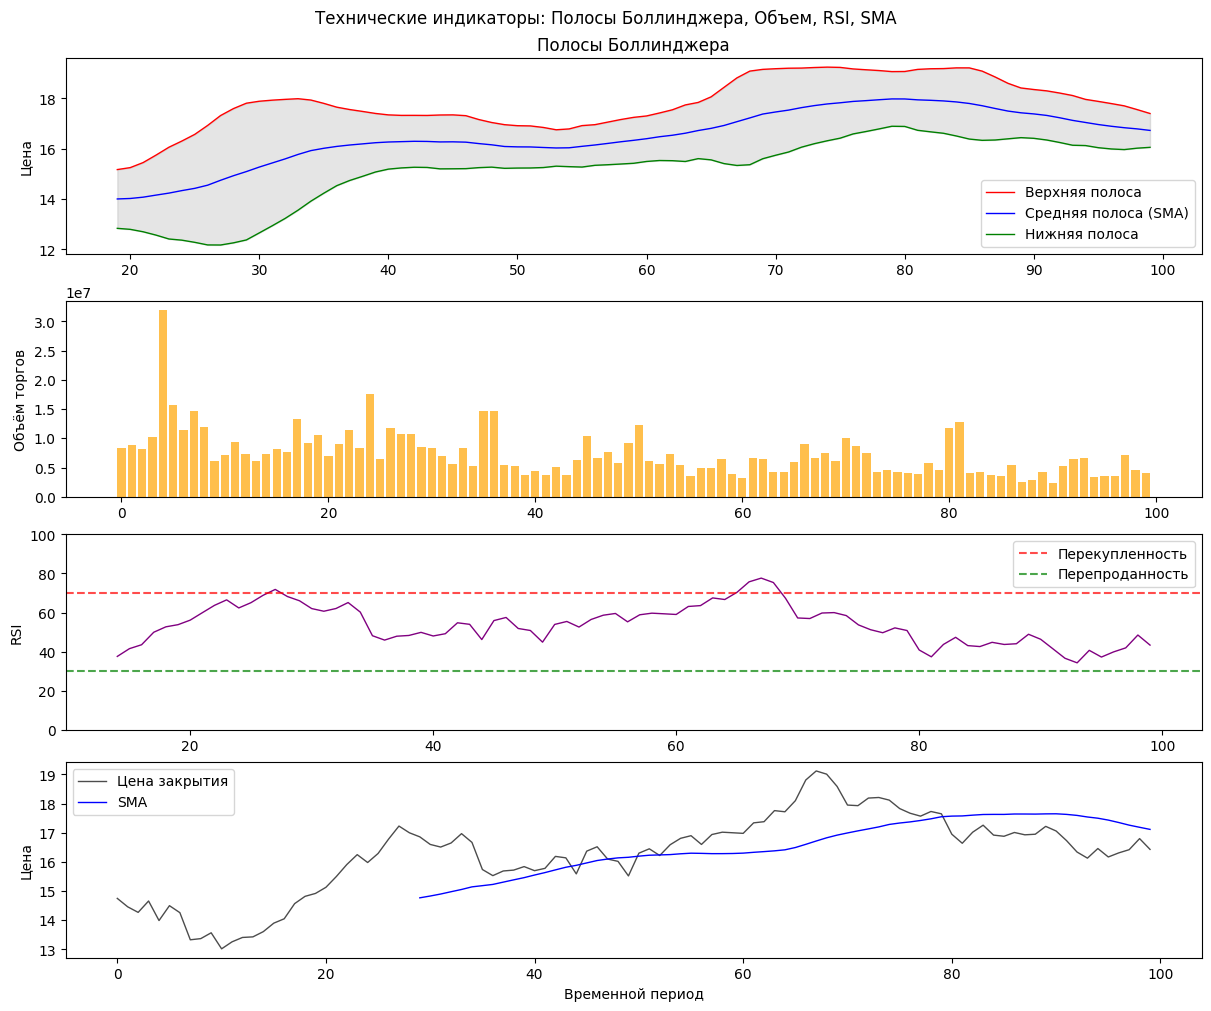

In [ ]:
import talib
import numpy as np
from talib import MA_Type
import matplotlib.pyplot as plt

#print ("Список всех индикаторов\n","\n".join(talib.get_functions()))

df = df[:100]
rsi = talib.RSI(np.array(df["close"], dtype=np.float64))
outputSMA = talib.SMA(np.array(df["close"], dtype=np.float64))

upper, middle, lower = talib.BBANDS(
    np.array(df["close"], dtype=np.float64),
    timeperiod=20,
    nbdevup=2,
    nbdevdn=2,
    matype=0
)

t = range(0, len(df["close"]))

fig, axs = plt.subplots(4, 1, layout='constrained', figsize=(12, 10))

axs[0].plot(t, upper, label='Верхняя полоса', color='red', linewidth=1)
axs[0].plot(t, middle, label='Средняя полоса (SMA)', color='blue', linewidth=1)
axs[0].plot(t, lower, label='Нижняя полоса', color='green', linewidth=1)
axs[0].fill_between(t, upper, lower, alpha=0.2, color='gray')
axs[0].set_ylabel('Цена')
axs[0].legend()
axs[0].set_title('Полосы Боллинджера')

axs[1].bar(t, df["volume"], color='orange', alpha=0.7)
axs[1].set_ylabel('Объём торгов')

axs[2].plot(t, rsi, color='purple', linewidth=1)
axs[2].axhline(y=70, color='r', linestyle='--', alpha=0.7, label='Перекупленность')
axs[2].axhline(y=30, color='g', linestyle='--', alpha=0.7, label='Перепроданность')
axs[2].set_ylabel('RSI')
axs[2].set_ylim(0, 100)
axs[2].legend()


axs[3].plot(t, df["close"], label='Цена закрытия', color='black', linewidth=1, alpha=0.7)
axs[3].plot(t, outputSMA, label='SMA', color='blue', linewidth=1)
axs[3].set_ylabel('Цена')
axs[3].legend()

plt.suptitle("Технические индикаторы: Полосы Боллинджера, Объем, RSI, SMA")
plt.xlabel('Временной период')
plt.show()

### Задание №4

Рассчитай технический индикатор "скользящая средняя" по потоковым (только полученным, свежим) данным используя  Streaming API

In [ ]:
%%capture
!pip install 'python-engineio==3.14.2'
!pip install 'python-socketio==4.3.1'

In [ ]:
from talib import stream

close = np.array(df["close"], dtype=np.float64)

output = talib.SMA(close) # the Function API для статических данных
latest = stream.SMA(close) # the Streaming API <- используй потоковый API
print ("статические данные ",output[-1], ", потоковые данные ", latest)

статические данные  17.115999999999996 , потоковые данные  17.116


In [ ]:
import talib
import numpy as np
from talib import stream
import socketio
import time
from collections import deque
import pandas as pd

class StreamingSMA:
    def __init__(self, period=20):
        self.period = period
        self.prices = deque(maxlen=period * 2)
        self.sma_values = []

    def add_price(self, price):
        self.prices.append(price)

        if len(self.prices) >= self.period:
            prices_array = np.array(self.prices, dtype=np.float64)
            stream_sma = stream.SMA(prices_array, timeperiod=self.period)
            self.sma_values.append(stream_sma)

            return stream_sma
        return None

sma_indicator = StreamingSMA(period=20)
sio = socketio.Client()

@sio.event
def connect():
    print("I'm connected!")
    sio.emit('login', {'userKey': 'wsfQsXX90onvUpylWgzQ'})

@sio.on('handshake')
def on_message(data):
    print('HandShake', data)
    sio.emit('symbolSub', {'symbol': 'EURUSD'})

@sio.on('price')
def on_message(data):
    try:
        if 'bid' in data and 'ask' in data:
            current_price = (float(data['bid']) + float(data['ask'])) / 2
            current_sma = sma_indicator.add_price(current_price)

            if current_sma is not None:
                print(f"Цена: {current_price:.5f}")
                print(f"SMA({sma_indicator.period}): {current_sma:.5f}")

                diff_percent = ((current_price - current_sma) / current_sma) * 100
                trend = "БЫЧИЙ" if diff_percent > 0 else "МЕДВЕЖИЙ"

                print(f"Тренд: {trend} ({diff_percent:+.2f}%)")
                print(f"Исторических точек SMA: {len(sma_indicator.sma_values)}")
                print("-" * 60)

    except Exception as e:
        print(f"Ошибка: {e}")

@sio.event
def disconnect():
    print('Отключен от сервера')

try:
    print("Запуск потокового анализа SMA...")
    sio.connect('https://marketdata.tradermade.com')
    symbols = ['EURUSD']
    for symbol in symbols:
        print(f"Подписываемся на {symbol}...")
        sio.emit('symbolSub', {'symbol': symbol})
    time.sleep(30)
    sio.disconnect()
except Exception as e:
    print(f"❌ Ошибка подключения: {e}")


Запуск потокового анализа SMA...
I'm connected!
Подписываемся на EURUSD...


In [ ]:
import random
prices = [1.1000 + random.uniform(-0.01, 0.01) for _ in range(100)]
sma_period = 20

for i in range(len(prices)):
    current_data = prices[:i+1]
    if len(current_data) >= sma_period:
        prices_array = np.array(current_data, dtype=np.float64)
        stream_sma = stream.SMA(prices_array, timeperiod=sma_period)
        static_sma = talib.SMA(prices_array, timeperiod=sma_period)

        print(f"Цена: {current_data[-1]:.5f}, Stream SMA: {stream_sma:.5f}, Static SMA: {static_sma[-1]:.5f}")

    time.sleep(0.1)

Цена: 1.09411, Stream SMA: 1.10056, Static SMA: 1.10056
Цена: 1.09816, Stream SMA: 1.10036, Static SMA: 1.10036
Цена: 1.09108, Stream SMA: 1.09976, Static SMA: 1.09976
Цена: 1.09620, Stream SMA: 1.09916, Static SMA: 1.09916
Цена: 1.10260, Stream SMA: 1.09968, Static SMA: 1.09968
Цена: 1.10986, Stream SMA: 1.10039, Static SMA: 1.10039
Цена: 1.10801, Stream SMA: 1.10061, Static SMA: 1.10061
Цена: 1.10636, Stream SMA: 1.10119, Static SMA: 1.10119
Цена: 1.09122, Stream SMA: 1.10086, Static SMA: 1.10086
Цена: 1.10570, Stream SMA: 1.10096, Static SMA: 1.10096
Цена: 1.10393, Stream SMA: 1.10131, Static SMA: 1.10131
Цена: 1.09729, Stream SMA: 1.10130, Static SMA: 1.10130
Цена: 1.09332, Stream SMA: 1.10069, Static SMA: 1.10069
Цена: 1.10019, Stream SMA: 1.10053, Static SMA: 1.10053
Цена: 1.10081, Stream SMA: 1.10053, Static SMA: 1.10053
Цена: 1.09998, Stream SMA: 1.10017, Static SMA: 1.10017
Цена: 1.10184, Stream SMA: 1.10033, Static SMA: 1.10033
Цена: 1.09924, Stream SMA: 1.09981, Static SMA: 

### Задание №5

Современный оркестратор Dagster.io даёт возможность **реактивно** запускать следующий этап конвейера данных (при изменении данных предыдущего этапа) используя [Сенсор](https://docs.dagster.io/guides/automate/asset-sensors).

Подключи Сенсор к функции daily_sales_data_sensor, реагирующий на изменение "daily_sales_data" и запускающий обновление weekly_report

In [ ]:
%%capture
!pip install dagster dagster-dg-cli

In [ ]:
import dagster as dg
from datetime import datetime

@dg.asset(description="ежедневный отчёт по стоимости чистых активов ПИФа")
def daily_sales_data(context: dg.AssetExecutionContext):
    context.log.info("Запускаю ежедневный отчёт СЧА")
    yield dg.MaterializeResult(value=df[-1:]["close"].to_list(), metadata={"отчёт СЧА на дату": datetime.now().isoformat()})


@dg.asset(description="еженедельный отчёт по стоимости чистых активов ПИФа")
def weekly_report(context: dg.AssetExecutionContext):
    context.log.info("Еженедельный отчёт СЧА готов")
    yield dg.MaterializeResult(metadata={"Еженедельный отчёт СЧА на дату": datetime.now().isoformat()})


my_job = dg.define_asset_job("Обновление еженедельного отчёта СЧА", [weekly_report])

@dg.sensor(job=my_job)
def daily_sales_data_sensor(context: dg.SensorEvaluationContext):
    asset_events = context.latest_materialization_records_by_key()

    if "daily_sales_data" in asset_events:
        latest_event = asset_events["daily_sales_data"]

        cursor = context.cursor or "0"
        if int(latest_event.storage_id) > int(cursor):
            context.update_cursor(latest_event.storage_id)
            return my_job.run_request_for_partition(
                run_key=f"weekly_report_{latest_event.storage_id}",
                partition_key=latest_event.partition_key if latest_event.partition_key else None
            )

    return None

print([_ for _ in daily_sales_data(None)],
      "\n",
      [_ for _ in weekly_report(None)])

2025-10-24 17:34:58 +0000 - dagster - INFO - system - Запускаю ежедневный отчёт СЧА
2025-10-24 17:34:58 +0000 - dagster - INFO - system - Еженедельный отчёт СЧА готов


[MaterializeResult(asset_key=None, metadata={'отчёт СЧА на дату': '2025-10-24T17:34:58.277407'}, check_results=[], data_version=None, tags=None, value=[16.43])] 
 [MaterializeResult(asset_key=None, metadata={'Еженедельный отчёт СЧА на дату': '2025-10-24T17:34:58.337211'}, check_results=[], data_version=None, tags=None, value=<class 'dagster._core.definitions.utils.NoValueSentinel'>)]
